# Import Necessery Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Better looking plots
plt.style.use('seaborn-v0_8')

pd.set_option('display.float_format', '{:.2f}'.format)

print("Import Successfull")

Import Successfull


# Import Dataframe and Inspect

In [16]:
df = pd.read_csv("hospital_stay_dataset.csv")

print("Shape", df.shape)

print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())
print("\nMissing Values")
print(df.isna().sum())

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

display(df.head())
print("\nDescriptive statistics – numeric columns:")
display(df.describe())

Shape (1000, 21)
Columns (21):
['patient_id', 'age', 'bmi', 'num_diagnoses', 'num_procedures', 'num_prev_admissions', 'lab_tests_ordered', 'severity_score', 'icu_admission', 'bp_systolic', 'cholesterol_level', 'comorbidity_score', 'dist_to_hospital_km', 'nurse_patient_ratio', 'readmission_within_30d', 'department', 'admission_type', 'insurance_type', 'gender', 'day_admitted', 'length_of_stay_days']

Missing Values
patient_id                0
age                       0
bmi                       0
num_diagnoses             0
num_procedures            0
num_prev_admissions       0
lab_tests_ordered         0
severity_score            0
icu_admission             0
bp_systolic               0
cholesterol_level         0
comorbidity_score         0
dist_to_hospital_km       0
nurse_patient_ratio       0
readmission_within_30d    0
department                0
admission_type            0
insurance_type            0
gender                    0
day_admitted              0
length_of_stay_days   

,dtype
patient_id,object
age,int64
bmi,float64
num_diagnoses,int64
num_procedures,int64
num_prev_admissions,int64
lab_tests_ordered,int64
severity_score,int64
icu_admission,int64
bp_systolic,int64


,patient_id,age,bmi,num_diagnoses,num_procedures,num_prev_admissions,lab_tests_ordered,severity_score,icu_admission,bp_systolic,...,comorbidity_score,dist_to_hospital_km,nurse_patient_ratio,readmission_within_30d,department,admission_type,insurance_type,gender,day_admitted,length_of_stay_days
0,P0001,70,20.50,2,7,15,17,10,1,189,...,1,70.40,0.13,1,Neurology,Emergency,Medicare,Female,Wednesday,72.30
1,P0002,19,28.50,7,0,3,22,3,1,187,...,5,7.80,0.79,0,Orthopedics,Emergency,Medicare,Male,Tuesday,34.60
2,P0003,50,40.70,9,5,15,28,5,1,189,...,10,65.50,0.16,1,Orthopedics,Urgent,Medicare,Male,Sunday,52.90
3,P0004,50,21.00,1,2,3,6,10,1,104,...,2,26.80,0.18,0,Cardiology,Urgent,Public,Male,Friday,36.70
4,P0005,85,30.20,1,3,2,2,3,0,126,...,6,62.70,0.57,0,Oncology,Emergency,Public,Female,Saturday,42.00



Descriptive statistics – numeric columns:


,age,bmi,num_diagnoses,num_procedures,num_prev_admissions,lab_tests_ordered,severity_score,icu_admission,bp_systolic,cholesterol_level,comorbidity_score,dist_to_hospital_km,nurse_patient_ratio,readmission_within_30d,length_of_stay_days
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,48.48,29.60,5.52,3.99,7.66,15.60,5.62,0.49,139.72,219.57,4.79,39.98,0.45,0.49,40.22
std,27.06,8.80,2.91,2.53,4.62,8.89,2.84,0.50,35.04,59.06,3.13,23.69,0.21,0.50,11.45
min,1.00,14.00,1.00,0.00,0.00,1.00,1.00,0.00,80.00,120.00,0.00,0.50,0.10,0.00,14.30
25%,25.00,22.10,3.00,2.00,4.00,8.00,3.00,0.00,109.00,168.00,2.00,18.95,0.26,0.00,31.40
50%,49.00,29.40,5.00,4.00,8.00,15.00,6.00,0.00,138.50,220.00,5.00,40.00,0.44,0.00,39.50
75%,72.00,37.30,8.00,6.00,12.00,24.00,8.00,1.00,169.00,272.00,7.00,61.30,0.64,1.00,47.90
max,95.00,45.00,10.00,8.00,15.00,30.00,10.00,1.00,200.00,320.00,10.00,80.00,0.80,1.00,75.10


# Quick look at target distribution

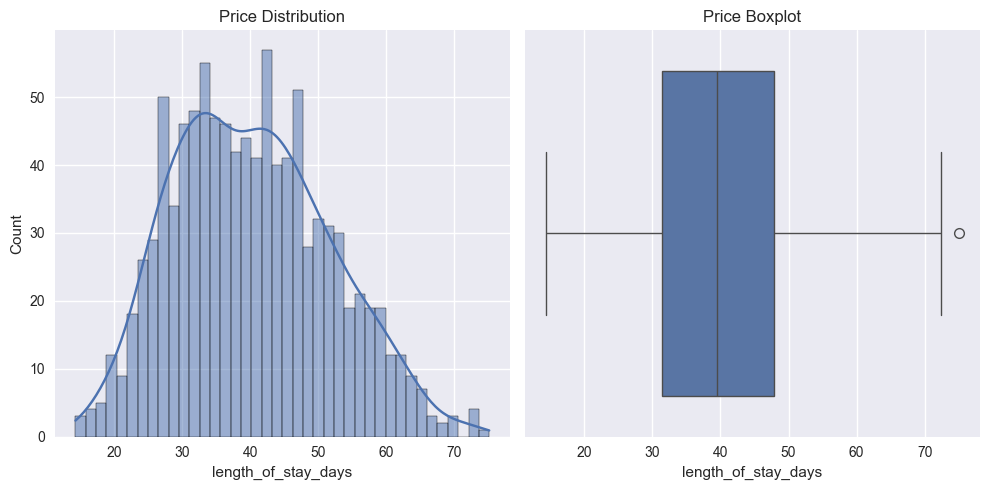

In [17]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df['length_of_stay_days'], bins = 40, kde=True)
plt.title("Price Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df['length_of_stay_days'])
plt.title("Price Boxplot")

plt.tight_layout()
plt.show()

# Prepare features and target

In [18]:
x = df.drop(['length_of_stay_days', 'patient_id'], axis = 1)
y = df['length_of_stay_days']

print("Features shape:", x.shape)
print("Target shape:  ", y.shape)

Features shape: (1000, 19)
Target shape:   (1000,)


# Define categorical and numerical columns

In [19]:
features = df.drop(columns = ['length_of_stay_days', 'patient_id'], axis = 1)

numeric_features = features.select_dtypes(['number', 'int64', 'float']).columns.tolist()
categorical_features = features.select_dtypes(['category', 'object']).columns.tolist()

print("Numeric Features: ", numeric_features)
print("Categorical Features: ", categorical_features)

Numeric Features:  ['age', 'bmi', 'num_diagnoses', 'num_procedures', 'num_prev_admissions', 'lab_tests_ordered', 'severity_score', 'icu_admission', 'bp_systolic', 'cholesterol_level', 'comorbidity_score', 'dist_to_hospital_km', 'nurse_patient_ratio', 'readmission_within_30d']
Categorical Features:  ['department', 'admission_type', 'insurance_type', 'gender', 'day_admitted']


# Create preprocessor + polynomial pipeline

In [20]:
degree = 2

# preprocessing process
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop = 'first', sparse_output=False), categorical_features)
    ]
)

print("Preprocessing Done!")

# creating pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=degree, include_bias= False)),
    ('regressor', LinearRegression())
])
model

Preprocessing Done!


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# Train / test split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size = 0.2,
    random_state = 42
)

print(f"Train set: {x_train.shape[0]:4d} rows  ({len(x_train)/len(x)*100:.1f}%)")
print(f"Test set : {x_test.shape[0]:4d} rows  ({len(x_test)/len(x)*100:.1f}%)")

Train set:  800 rows  (80.0%)
Test set :  200 rows  (20.0%)


# Train the model

In [22]:
model.fit(x_train, y_train)

print("Model Trained")

Model Trained


# Predictions & evaluation function

In [23]:
y_pred_train = model.predict(x_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("┌────────────────────── TRAIN ──────────────────────┐")
print(f"│ MAE  = {mae_train:10.3f}                                 │")
print(f"│ RMSE = {rmse_train:10.3f}                                 │")
print(f"│ R²   = {r2_train:10.3f}                                 │")
print("└───────────────────────────────────────────────────┘")

y_pred_test = model.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("┌────────────────────── TEST ───────────────────────┐")
print(f"│ MAE  = {mae_test:10.3f}                                 │")
print(f"│ RMSE = {rmse_test:10.3f}                                 │")
print(f"│ R²   = {r2_test:10.3f}                                 │")
print("└───────────────────────────────────────────────────┘")

┌────────────────────── TRAIN ──────────────────────┐
│ MAE  =      0.790                                 │
│ RMSE =      0.986                                 │
│ R²   =      0.993                                 │
└───────────────────────────────────────────────────┘
┌────────────────────── TEST ───────────────────────┐
│ MAE  =      2.146                                 │
│ RMSE =      2.780                                 │
│ R²   =      0.941                                 │
└───────────────────────────────────────────────────┘


# Visual comparison (actual vs predicted)

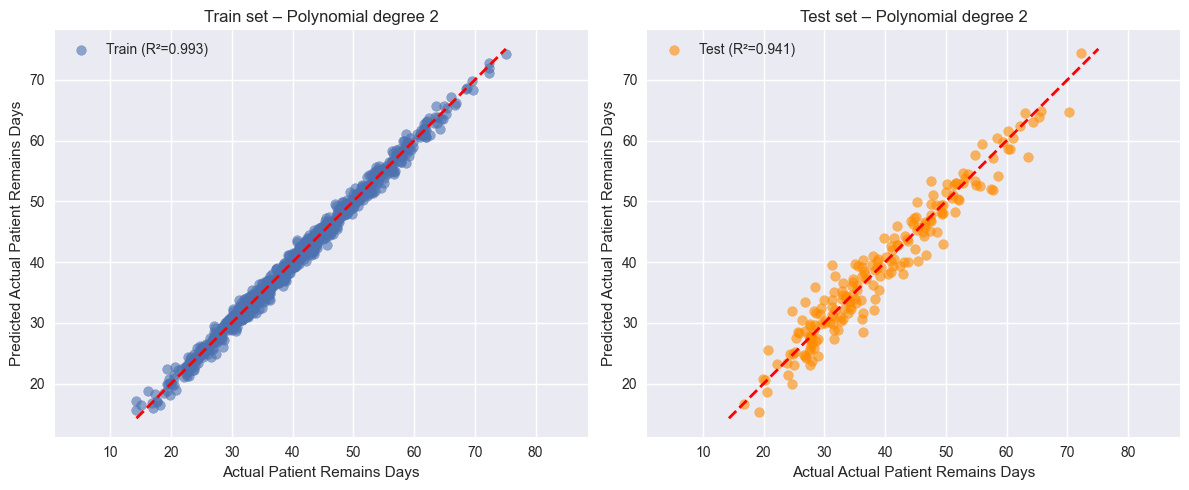

In [24]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1,2,1)
plt.scatter(y_train, y_pred_train, alpha=0.6, 
            label=f'Train (R²={r2_score(y_train, y_pred_train):.3f})')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Patient Remains Days")
plt.ylabel("Predicted Actual Patient Remains Days")
plt.title(f"Train set – Polynomial degree {degree}")
plt.legend()
plt.axis('equal')

# Test
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='darkorange', 
            label=f'Test (R²={r2_score(y_test, y_pred_test):.3f})')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Actual Patient Remains Days")
plt.ylabel("Predicted Actual Patient Remains Days")
plt.title(f"Test set – Polynomial degree {degree}")
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()

# COMPARE POLYNOMIAL DEGREES (1–4)

In [25]:
results = []

for degree in [1, 2, 3, 4]: 
    model = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=degree, include_bias= False)),
    ('regressor', LinearRegression())
])
    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    results.append({
        'degree':     degree,
        'R² train':   r2_score(y_train, y_pred_train),
        'R² test':    r2_score(y_test,  y_pred_test),
        'R² diff':    r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test),
        'RMSE train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE test':  np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        'RMSE diff':  np.sqrt(mean_squared_error(y_train, y_pred_train)) - 
                      np.sqrt(mean_squared_error(y_test,  y_pred_test))
    })

df_results = pd.DataFrame(results).round(4)
df_results
# #Styled output
# styled = df_results.style\
#     .background_gradient(subset=['R² test'], cmap='RdYlGn')\
#     .background_gradient(subset=['RMSE test'], cmap='YlOrRd_r')\
#     .format({
#         'R² train':   '{:.4f}',
#         'R² test':    '{:.4f}',
#         'R² diff':    '{:+.4f}',
#         'RMSE train': '{:,.0f}',
#         'RMSE test':  '{:,.0f}',
#         'RMSE diff':  '{:+.0f}'
#     })\
#     .highlight_max(subset=['R² test'], color='#dedda')\
#     .highlight_min(subset=['RMSE test'], color='#dedda')

# print("Model comparison across polynomial degrees:")
# display(styled)

,degree,R² train,R² test,R² diff,RMSE train,RMSE test,RMSE diff
0,1,0.96,0.96,0.00,2.32,2.38,-0.06
1,2,0.99,0.94,0.05,0.99,2.78,-1.79
2,3,1.00,0.87,0.13,0.00,4.07,-4.07
3,4,1.00,0.79,0.21,0.00,5.27,-5.27


# FINAL MODEL WITH BEST DEGREE + VISUALIZATION

Final model (degree 1) performance on test set:
• R²   = 0.9567
• RMSE = 2
• MAE  = 2



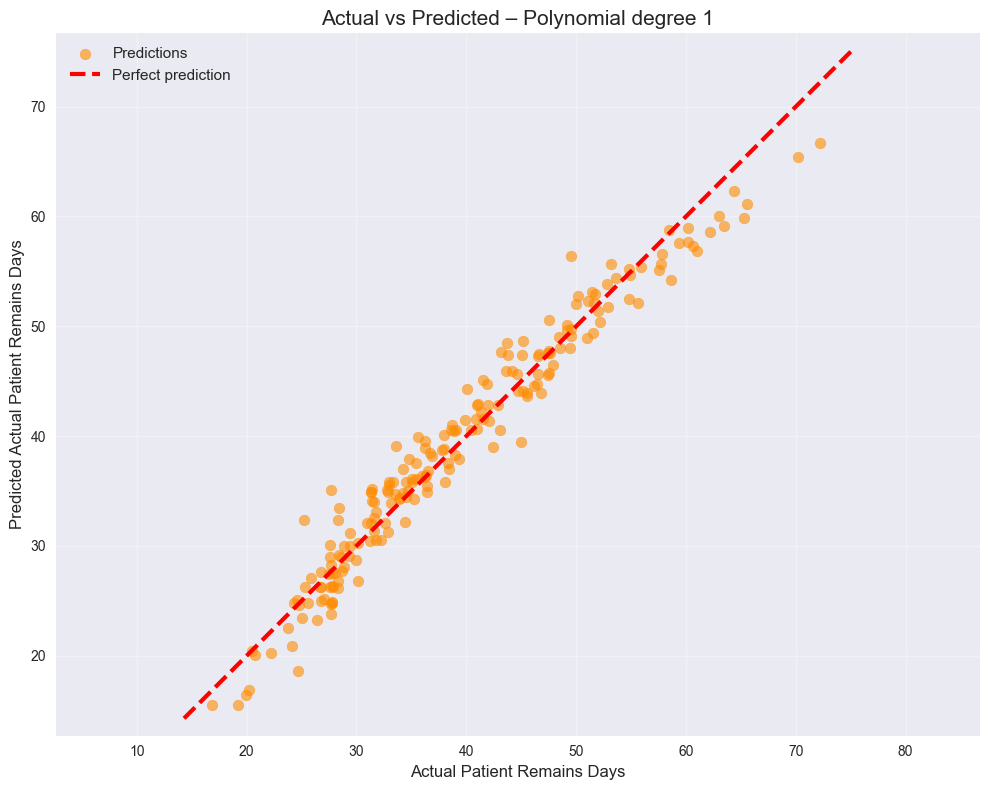

In [29]:
best_degree = df_results.loc[df_results['R² test'].idxmax(), 'degree']

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly',         PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model',        LinearRegression())
])

final_pipe.fit(x_train, y_train)

y_pred_test = final_pipe.predict(x_test)

mae   = mean_absolute_error(y_test, y_pred_test)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2    = r2_score(y_test, y_pred_test)

print(f"Final model (degree {best_degree}) performance on test set:")
print(f"• R²   = {r2:.4f}")
print(f"• RMSE = {rmse:,.0f}")
print(f"• MAE  = {mae:,.0f}\n")

# Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=60, color='darkorange', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, label='Perfect prediction')
plt.xlabel("Actual Patient Remains Days", fontsize=12)
plt.ylabel("Predicted Actual Patient Remains Days", fontsize=12)
plt.title(f"Actual vs Predicted – Polynomial degree {best_degree}", fontsize=15)
plt.legend(fontsize=11)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# EXAMPLE PREDICTION

In [33]:
# Example new patient — keep categories as strings (no manual encoding needed)
example_patient = pd.DataFrame([{
    'age': 67,
    'bmi': 28.7,
    'num_diagnoses': 6,
    'num_procedures': 4,
    'num_prev_admissions': 3,
    'lab_tests_ordered': 12,
    'severity_score': 6,
    'icu_admission': 0,
    'bp_systolic': 142,
    'cholesterol_level': 198,
    'comorbidity_score': 5,
    'dist_to_hospital_km': 14.5,
    'nurse_patient_ratio': 0.48,
    'readmission_within_30d': 0,
    'department': 'Cardiology',
    'admission_type': 'Urgent',
    'insurance_type': 'Medicare',
    'gender': 'Male',
    'day_admitted': 'Tuesday'
}])

# Important: make sure all columns that were in training are present
# (if some are missing → pipeline will complain)
# You can add dummy values for any missing columns if needed, e.g.:
# example_patient['some_missing_col'] = 0

# Predict — the ColumnTransformer + OneHotEncoder handles strings automatically
try:
    predicted_stay = final_pipe.predict(example_patient)[0]
    print(f"Predicted length of hospital stay: {predicted_stay:.1f} days")
except Exception as e:
    print("Prediction failed. Error message:")
    print(str(e))
    print("\nPossible causes:")
    print("1. Column names / order do not match training data")
    print("2. Missing columns in example_patient")
    print("3. final_pipe was not fitted yet (run training cell first)")

Predicted length of hospital stay: 39.8 days
